# Godot DQN Agent

This notebook runs the training loop, connecting the `DQNAgent` to the Godot environment. It automatically launches Godot in **headless mode** to massively speed up training without rendering graphics.

In [1]:
import asyncio
import websockets
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import subprocess
import os
import time

MODEL_PATH = os.path.abspath(os.path.join(os.getcwd(), "dqn_model.pth"))

# Import our modular DQN components
from dqn_agent import DQNAgent

class GodotEnv:
    def __init__(self, host='127.0.0.1', port=11000):
        self.host = host
        self.port = port
        self.server = None
        self.websocket = None
        self.last_state = []
        self.last_reward = 0.0
        self.last_done = False
        self.last_score = 0.0
        self.last_info = {}
        self.response_event = asyncio.Event()

    async def start_server(self):
        try:
            self.server = await websockets.serve(self.handler, self.host, self.port)
        except OSError as e:
            raise RuntimeError(
                f"Failed to bind ws://{self.host}:{self.port} (port already in use?). "
                "Restart the notebook kernel or stop the previous training run."
            ) from e
        print(f"WebSocket server started at ws://{self.host}:{self.port}")

    async def stop_server(self):
        if self.server is not None:
            self.server.close()
            await self.server.wait_closed()
            self.server = None
            print("WebSocket server stopped.")

    async def handler(self, websocket, path=None):
        print("Godot connected!")
        self.websocket = websocket
        try:
            async for message in websocket:
                data = json.loads(message)
                self.last_state = data.get('state', [])
                self.last_reward = data.get('reward', 0.0)
                self.last_done = data.get('done', False)
                self.last_score = data.get('score', 0.0)
                self.last_info = data.get('info', {})
                self.response_event.set()
        except websockets.exceptions.ConnectionClosed:
            print("Godot disconnected.")
            self.websocket = None
            self.response_event.set()

    async def step(self, action: int):
        if self.websocket:
            self.response_event.clear()
            try:
                await self.websocket.send(json.dumps({"action": action}))
            except websockets.exceptions.ConnectionClosed:
                print("Godot disconnected during step; closing connection.")
                self.websocket = None
                return [], 0.0, True, 0.0, {}
            if await self._wait_for_response():
                return self.last_state, self.last_reward, self.last_done, self.last_score, self.last_info
        return [], 0.0, True, 0.0, {}

    async def reset(self):
        if self.websocket:
            self.response_event.clear()
            try:
                await self.websocket.send(json.dumps({"command": "reset"}))
            except websockets.exceptions.ConnectionClosed:
                print("Godot disconnected during reset; closing connection.")
                self.websocket = None
                return []
            if await self._wait_for_response():
                return self.last_state
        return []

    async def _wait_for_response(self, timeout: float = 30.0) -> bool:
        try:
            await asyncio.wait_for(self.response_event.wait(), timeout=timeout)
            return True
        except asyncio.TimeoutError:
            print("Timed out waiting for Godot response; closing connection.")
            self.websocket = None
            return False


def cleanup_stray_godot(project_path: str):
    """Kill orphaned headless Godot instances of this project (left behind by a
    hard-killed kernel) so they cannot hijack the WebSocket connection."""
    if os.name == "nt":
        try:
            ps = ("Get-CimInstance Win32_Process | Where-Object { "
                  "$_.Name -in @('godot.console.exe','godot.exe') -and "
                  "$_.CommandLine -match [regex]::Escape('" + project_path + "') } | "
                  "Select-Object -ExpandProperty ProcessId")
            result = subprocess.run(["powershell", "-NoProfile", "-Command", ps],
                                    capture_output=True, text=True, timeout=30)
            pids = [p.strip() for p in result.stdout.split() if p.strip().isdigit()]
            for pid in pids:
                subprocess.run(["taskkill", "/PID", pid, "/T", "/F"],
                               capture_output=True, timeout=10)
            if pids:
                print(f"Cleaned up {len(pids)} stray headless Godot process(es).")
        except Exception as e:
            print(f"Warning: stray Godot cleanup failed: {e}")
    else:
        try:
            subprocess.run(["pkill", "-f", "godot.*" + project_path],
                           capture_output=True, timeout=10)
        except Exception:
            pass

async def wait_for_godot(env: GodotEnv, timeout: float = 30.0):
    start = time.time()
    while env.websocket is None:
        if time.time() - start > timeout:
            raise RuntimeError(f"Godot did not connect to ws://{env.host}:{env.port} within {timeout:.0f}s. Check the Godot executable path and that the port is free.")
        await asyncio.sleep(0.5)


In [2]:
def plot_metrics(episode_rewards, moving_avg, epsilons, losses):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # Reward Plot
    ax1.plot(episode_rewards, alpha=0.3, color='blue', label='Episode Reward')
    ax1.plot(moving_avg, color='red', label='Moving Avg')
    ax1.set_title('Training Rewards')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.legend()

    # Loss Plot
    ax2.plot(losses, color='purple')
    ax2.set_title('Average Loss per Episode')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Loss')

    # Epsilon Plot
    ax3.plot(epsilons, color='orange')
    ax3.set_title('Epsilon Decay')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Epsilon')

    plt.tight_layout()
    # Update the figure in place instead of clearing the cell output,
    # so printed episode status lines stay visible.
    if plot_metrics.fig_handle is None:
        plot_metrics.fig_handle = display(fig, display_id="training_metrics")
    else:
        plot_metrics.fig_handle.update(fig)
    plt.close(fig)

plot_metrics.fig_handle = None


## Phase 4: Training Loop (Headless)
Running this cell will automatically launch Godot in headless mode and start the training process.

WebSocket server started at ws://127.0.0.1:11000
Launching Godot Headless at: c:\Users\khory\Desktop\godot-dqn-agent\godot-src
Godot connected!
Logging training metrics to training_log_20260828_201440.csv


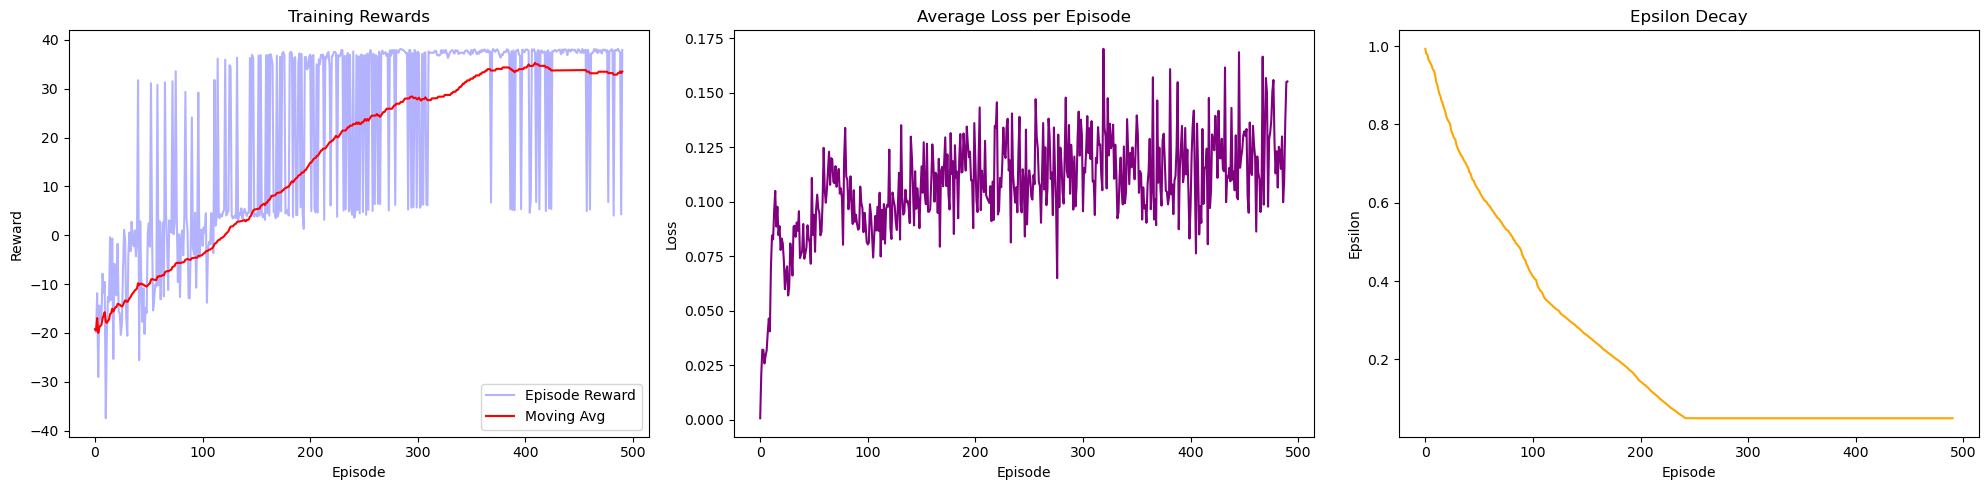

Episode 0/500 | Steps: 291 | Reward: -19.21 | Loss: 0.0006 | Epsilon: 0.99
New best moving average (-17.71)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_10.pth
Episode 10/500 | Steps: 756 | Reward: -37.46 | Loss: 0.0702 | Epsilon: 0.91
New best moving average (-17.53)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_12.pth
New best moving average (-17.24)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_13.pth
New best moving average (-16.12)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_14.pth
New best moving average (-15.95)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_15.pth
New best moving average (-15.05)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_16.pth
New best moving average (-14.75)! Saved model to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model_best_19.pth
New best moving average

In [3]:
async def train():
    # Hyperparameters
    config = {
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_min": 0.05,
        "epsilon_decay_steps": 40000,
        "batch_size": 64,
        "learning_rate": 0.001,
        "buffer_size": 50000
    }

    state_size = 9
    action_size = 6
    agent = DQNAgent(state_size, action_size, config)
    env = GodotEnv()

    await env.start_server()

    # Launch Godot in Headless Mode

    # Subprocess avoids blocking Jupyter

    num_episodes = 500

    episode_rewards = []
    moving_avg = []
    epsilons = []
    episode_losses = []
    episodes_run = 0
    interrupted = False
    godot_process = None

    try:
        godot_exe = "godot" if os.name == "posix" else os.path.expanduser(r"~\scoop\apps\godot\current\godot.console.exe")
        project_path = os.path.abspath(os.path.join("..", "godot-src"))
        print(f"Launching Godot Headless at: {project_path}")
        cleanup_stray_godot(project_path)
        godot_process = subprocess.Popen([godot_exe, "--path", project_path])
        # Wait for Godot to connect (raises RuntimeError on timeout)
        await wait_for_godot(env)
        best_moving_avg = -float("inf")
        import csv
        from datetime import datetime
        log_filename = f"training_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        with open(log_filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Episode', 'Steps', 'Reward', 'MovingAvg', 'Loss', 'Epsilon'])
        print(f"Logging training metrics to {log_filename}")

        for episode in range(num_episodes):
            state = await env.reset()
            total_reward = 0
            total_loss = 0
            done = False
            step_count = 0

            while not done and env.websocket is not None:
                action = agent.get_action(state)
                next_state, reward, done, score, info = await env.step(action)

                if state and next_state and len(state) == state_size and len(next_state) == state_size:
                    agent.memory.add(state, action, reward, next_state, done)
                    loss = agent.train_step()
                    agent.update_epsilon()
                    if agent.total_steps % 1000 == 0:
                        agent.update_target_network()
                else:
                    loss = 0.0

                state = next_state
                total_reward += reward
                total_loss += loss
                step_count += 1

                # Failsafe for getting stuck
                if step_count > 1000:
                    done = True

            if env.websocket is None:
                raise RuntimeError("Godot disconnected during training.")

            episodes_run += 1

            episode_rewards.append(total_reward)
            epsilons.append(agent.epsilon)
            episode_losses.append(total_loss / max(1, step_count))

            # Calculate moving average
            if len(episode_rewards) >= 100:
                moving_avg.append(np.mean(episode_rewards[-100:]))
            else:
                moving_avg.append(np.mean(episode_rewards))

            current_avg = moving_avg[-1]
            with open(log_filename, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([episode, step_count, total_reward, current_avg, episode_losses[-1], agent.epsilon])

            if current_avg > best_moving_avg and episode >= 10:
                best_moving_avg = current_avg
                import torch
                best_path = os.path.abspath(os.path.join(os.getcwd(), f"dqn_model_best_{episode}.pth"))
                torch.save(agent.policy_net.state_dict(), best_path)
                print(f"New best moving average ({best_moving_avg:.2f})! Saved model to {best_path}")

            if episode > 0 and episode % 50 == 0:
                import torch
                ckpt_path = os.path.abspath(os.path.join(os.getcwd(), f"dqn_model_ep{episode}.pth"))
                torch.save(agent.policy_net.state_dict(), ckpt_path)

            if episode % 10 == 0:
                plot_metrics(episode_rewards, moving_avg, epsilons, episode_losses)
                print(f"Episode {episode}/{num_episodes} | Steps: {step_count} | Reward: {total_reward:.2f} | Loss: {episode_losses[-1]:.4f} | Epsilon: {agent.epsilon:.2f}")

    except RuntimeError as e:
        print(f"Training aborted: {e}")
    except KeyboardInterrupt:
        interrupted = True
        print("Training interrupted manually.")
    finally:
        # Only overwrite the saved model if training finished or was interrupted manually.
        # An aborted run (e.g. Godot disconnect) must not clobber a good checkpoint.
        import torch
        if episodes_run == num_episodes or interrupted:
            torch.save(agent.policy_net.state_dict(), MODEL_PATH)
            print(f"Model saved to {MODEL_PATH}")
        elif episodes_run > 0:
            print("Training aborted early; existing model NOT overwritten.")
        else:
            print("No episodes completed; skipping model save.")

        # Kill Godot headless process safely
        if godot_process is not None:
            godot_process.terminate()
            print("Godot Headless terminated.")

        # Release the port so the cell can be re-run
        await env.stop_server()

await train()

## Phase 5: Evaluation & Visualization
Run this cell to evaluate the agent after training. The agent will act deterministically (Epsilon = 0).

In [4]:
async def test_agent():
    import time
    config = {
        "gamma": 0.99,
        "epsilon_start": 0.0,
        "epsilon_min": 0.0,
        "batch_size": 64,
        "learning_rate": 0.001,
        "buffer_size": 1000
    }

    agent = DQNAgent(9, 6, config)

    import torch
    import os
    if os.path.exists(MODEL_PATH):
        try:
            agent.policy_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
            agent.policy_net.eval()
            print("Loaded trained weights.")
        except Exception as e:
            print(f"Warning: failed to load {MODEL_PATH} ({e}); evaluating an untrained agent.")
    else:
        print(f"Warning: no model found at {MODEL_PATH}; evaluating an untrained agent.")

    env = GodotEnv()
    await env.start_server()
    godot_process = None

    try:
        godot_exe = "godot" if os.name == "posix" else os.path.expanduser(r"~\scoop\apps\godot\current\godot.console.exe")
        project_path = os.path.abspath(os.path.join("..", "godot-src"))
        cleanup_stray_godot(project_path)
        godot_process = subprocess.Popen([godot_exe, "--path", project_path])
        await wait_for_godot(env)
        best_moving_avg = -float("inf")
        import csv
        from datetime import datetime
        log_filename = f"training_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        with open(log_filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Episode', 'Steps', 'Reward', 'MovingAvg', 'Loss', 'Epsilon'])
        print(f"Logging training metrics to {log_filename}")

        test_episodes = 50

        metrics = {
            "total_reward": 0.0,
            "total_score": 0.0,
            "total_apples": 0,
            "completed": 0,
            "snail_deaths": 0,
            "fall_deaths": 0,
            "total_distance": 0.0,
            "godot_time": 0.0,
            "wall_time": 0.0
        }

        for episode in range(test_episodes):
            start_wall_time = time.time()
            state = await env.reset()
            total_reward = 0
            done = False
            step_count = 0
            cause_of_death = "unknown"
            max_x = 0.0
            score = 0.0

            while not done and env.websocket is not None:
                action = agent.get_action(state)
                next_state, reward, done, score, info = await env.step(action)
                state = next_state
                total_reward += reward
                step_count += 1

                if info.get("distance_x", 0.0) > max_x:
                    max_x = info.get("distance_x", 0.0)
                if info.get("cause_of_death", "") != "":
                    cause_of_death = info.get("cause_of_death", "")

                if step_count > 1000:
                    break

            if env.websocket is None:
                raise RuntimeError("Godot disconnected during evaluation.")

            wall_time = time.time() - start_wall_time
            godot_time = step_count * 4 * (1.0 / 60.0)

            metrics["total_reward"] += total_reward
            metrics["total_score"] += score
            metrics["total_apples"] += (score / 10.0)
            metrics["total_distance"] += max_x
            metrics["godot_time"] += godot_time
            metrics["wall_time"] += wall_time

            if cause_of_death == "completed":
                metrics["completed"] += 1
            elif cause_of_death == "snail":
                metrics["snail_deaths"] += 1
            elif cause_of_death == "fall":
                metrics["fall_deaths"] += 1

            print(f"Test {episode+1} | Score: {score} | Reward: {total_reward:.2f} | Death: {cause_of_death}")

        print("\n" + "="*80)
        print(f"{'- Experiment':<20} | {'Test Episodes':<13} | {'Average Reward':<14} | {'Average Score':<13} | {'Average Apples':<14} | {'Completion Rate %':<17} | {'Snail Avoidance %':<17} | {'Snail Collision %':<17} | {'Fall Rate %':<11} | {'Average Distance':<16} | {'Average Godot Episode Time':<26} | {'Average Wall-clock Time':<23}")
        print("="*80)

        avg_reward = metrics["total_reward"] / test_episodes
        avg_score = metrics["total_score"] / test_episodes
        avg_apples = metrics["total_apples"] / test_episodes
        comp_rate = (metrics["completed"] / test_episodes) * 100.0
        col_rate = (metrics["snail_deaths"] / test_episodes) * 100.0
        avoid_rate = 100.0 - col_rate
        fall_rate = (metrics["fall_deaths"] / test_episodes) * 100.0
        avg_dist = metrics["total_distance"] / test_episodes
        avg_g_time = metrics["godot_time"] / test_episodes
        avg_w_time = metrics["wall_time"] / test_episodes

        print(f"{'- Current Model':<20} | {test_episodes:<13} | {avg_reward:<14.3f} | {avg_score:<13.2f} | {avg_apples:<14.2f} | {comp_rate:<17.1f} | {avoid_rate:<17.1f} | {col_rate:<17.1f} | {fall_rate:<11.1f} | {avg_dist:<16.3f} | {avg_g_time:<26.3f} | {avg_w_time:<23.3f}")
        print("="*80)

    except RuntimeError as e:
        print(f"Evaluation aborted: {e}")
    finally:
        if godot_process is not None:
            godot_process.terminate()
            print("Evaluation finished. Godot Headless terminated.")
        await env.stop_server()

await test_agent()


Loaded trained weights.
WebSocket server started at ws://127.0.0.1:11000
Godot connected!
Logging training metrics to training_log_20260828_214127.csv
Test 1 | Score: 20.0 | Reward: 38.18 | Death: completed
Test 2 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 3 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 4 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 5 | Score: 20.0 | Reward: 38.18 | Death: completed
Test 6 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 7 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 8 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 9 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 10 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 11 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 12 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 13 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 14 | Score: 20.0 | Reward: 38.01 | Death: completed
Test 15 | Score: 20.0 | Reward: 38.01 | Death: completed
Tes